<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/code/Key_Authors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Load Data

In [1]:
import pickle
import re
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfTransformer
import pprint
from tabulate import tabulate
import matplotlib.pyplot as plt

In [2]:
# Connect to Goole Drive to use the data.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Data
output_dir = "/content/drive/Shareddrives/KeyBoostAuthor/data/"
# output_dir = "/dt/puzis/cnalab/KeyAuthors/"

with open(output_dir + '/israel_and_the_region.pkl', 'rb') as f:
    df = pickle.load(f)

# Print df
df.head()

,c_claim_id,c_post_id,url,author,content,date,title,description,url_right,verdict_date,keywords,domain,verdict,category,sub_category
0,007677fd-d100-3f20-936e-3dea041cfb1d,00ef3764-f159-3166-b3e3-8b1147aed472,https://twitter.com/karmel80/status/3367449316...,karmel80,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
1,007677fd-d100-3f20-936e-3dea041cfb1d,01062bf4-590c-306d-b194-809d4c12b8b0,https://twitter.com/MynameRillo/status/3967710...,MynameRillo,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
2,007677fd-d100-3f20-936e-3dea041cfb1d,0153a78a-de08-35ea-b9e2-d717e9b34ae0,https://twitter.com/JakobDrud/status/290556648...,JakobDrud,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
3,007677fd-d100-3f20-936e-3dea041cfb1d,02803736-bdab-3ff9-b5f6-933492f3b732,https://twitter.com/uk_radio/status/3499458660...,uk_radio,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
4,007677fd-d100-3f20-936e-3dea041cfb1d,02bae70c-0075-3954-8fe0-24f62d068286,https://twitter.com/DesMoinesNews/status/39672...,DesMoinesNews,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None


# Data Preprocessing

In [4]:
# Encode 'title' categories as numeric codes in 'topic' column
df['topic'] = df['title'].astype('category').cat.codes

#{topic_id: topic}
topic_id_to_title = dict(enumerate(df['title'].astype('category').cat.categories))


In [5]:
df = df[['c_post_id', 'title', 'content', 'date', 'topic' , 'author']]
df.head()

,c_post_id,title,content,date,topic,author
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews


In [6]:
# Wrap long text in the 'content' column to a max width so it will be printed nicely.
from textwrap import fill
df['content'] = df['content'].apply(lambda x: fill(str(x), width=60))

# Extracting Key Entity

In [7]:
# Extracting hashtags from a text and remove spaces.
def extract_hashtags(text):
    # Find all hashtag
    raw_hashtags = re.findall(r'#\s*\w+', text)
    # Remove spaces
    cleaned_hashtags = [re.sub(r'\s+', '', hashtag) for hashtag in raw_hashtags]
    return cleaned_hashtags

def extract_urls(text):
    url_pattern = r'https?://\S+'
    return re.findall(url_pattern, text)

def extract_user_mentions(text):
    mention_pattern = r'@\w+'
    return re.findall(mention_pattern, text)


# Apply the extract_hashtags function to the content of each related post
df['hashtags'] = df['content'].apply(extract_hashtags)
# df['extracted_urls'] = df['content'].apply(extract_urls)
df['user_mentions'] = df['content'].apply(extract_user_mentions)
# df['author'] = df['author'].apply(lambda s: s if isinstance(s, list) else [s]) # Wraps inside a list.

df.head()


,c_post_id,title,content,date,topic,author,hashtags,user_mentions
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[]
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[]
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[]
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[]
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[]


# TF_IDF
We use *TF-IDF* to identify which entities (e.g. hashtag or mention) are most important to each topic by measuring how frequently they appear in a topic and how unique they are across all topics.  
In *TF-IDF terminology*, we treat each **topic** as a **document** and each **entity**  as a **term**.


## Calculating entities TF-IDF score

### Calculating TF

In [8]:
def compute_tf_entity_by_topic(df, topic_col_name, entity_col_name):
    """
    Computes normalized term frequency of entities per topic.
    Args:
        df (DataFrame): Input DataFrame.
        topic_col_name (str): Column name with topic IDs.
        entity_col_name (str): Column name with lists of entities.
    Returns:
        dict: {topic: {entity: normalized_frequency}}
    """
    tf = defaultdict(lambda: defaultdict(int))

    # Count entity instances in the topic
    for _, row in df.iterrows():
        topic = row[topic_col_name] #the numeric uniq value of the topic.
        entities = row[entity_col_name]
        for entity in entities:
            tf[topic][entity] += 1

    # Normalize counts by total number of entities in each topic
    for topic in tf:
        total = sum(tf[topic].values())
        if total > 0:
            for entity in tf[topic]:
                tf[topic][entity] /= total

    return tf
'''
Idea 1: Use `lowercase()` or remove-spaces on entities as a form of stemming suitable for social media.
Idea 2: Use a logarithmic formula to handle big data.
'''

tf_hashtags = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='hashtags')
# tf_urls = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='extracted_urls')
tf_mentions = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='user_mentions')
tf_author = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='author')

# pprint.pprint(tf_hashtags)

### Calculating IDF


In [9]:
# Calculate DF (document frequency)

def compute_document_frequency(tf_dict):
    """
    Counts how many topics each entity appears in.
    Args:
        tf_dict (dict): {topic: {entity: tf_value}}
    Returns:
        dict: {entity: document_frequency}
    """
    df_dict = defaultdict(int)
    for topic, entities_dict in tf_dict.items():
        for entity in entities_dict:
            df_dict[entity] += 1
    return df_dict

df_hashtags = compute_document_frequency(tf_hashtags)
# df_urls = compute_document_frequency(tf_urls)
df_mentions = compute_document_frequency(tf_mentions)
df_author = compute_document_frequency(tf_author)

In [10]:
# Calculate IDF (document frequency)
def compute_idf(tf_dict, df_dict):
    """
    Computes IDF for each entity.
    Args:
        tf_dict (dict): {topic: {entity: tf}}.
        df_dict (dict): {entity: document frequency}.
    Returns:
        dict: {entity: idf score}.
    """
    num_of_topics = len(tf_dict)
    idf_dict = {entity: np.log(num_of_topics / (1 + df_dict[entity])) for entity in df_dict}
    return idf_dict

idf_hashtags = compute_idf(tf_hashtags, df_hashtags)
# idf_urls = compute_idf(tf_urls, df_urls)
idf_mentions = compute_idf(tf_mentions, df_mentions)
idf_author = compute_idf(df_author, df_author)

### Calculating TF * IDF


In [11]:
def compute_entity_tfidf_scores(entity_tf_dict, entity_idf_dict):
    """
    Computes TF-IDF scores per entity per topic.
    Args:
        entity_tf_dict (dict): {topic: {entity: tf_value}}
        entity_idf_dict (dict): {entity: idf_value}
    Returns:
        dict: {topic: {entity: tfidf_score}}
    """
    entity_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for topic, entity_tf_counts_dict in entity_tf_dict.items():
        for entity, tf in entity_tf_counts_dict.items():
            idf = entity_idf_dict.get(entity, 0.0)
            entity_tfidf_dict[topic][entity] = tf * idf
    return entity_tfidf_dict

hashtags_tfidf_dict = compute_entity_tfidf_scores(tf_hashtags, idf_hashtags)
# urls_tfidf_dict = compute_entity_tfidf_scores(tf_urls, idf_urls)
mention_tfidf_dict = compute_entity_tfidf_scores(tf_mentions, idf_mentions)

In [12]:
def compute_post_entities_tfidf_scores(row, entity_tfidf_dict, entity_type, topic_col_name='topic'):
    """
    Calculate the total TF-IDF score for one entity type in a post's topic.
    Args:
        row (pd.Series): A row from the DataFrame.
        entity_tfidf_dict (dict): {topic: {entity: tfidf_score}}.
        entity_type (str): The entity column in the row (e.g., 'hashtags', 'mentions').
        topic_col_name (str): Name of the topic column.
    Returns:
        float: Total TF-IDF score for that entity type in the post.
    """
    topic = row[topic_col_name]
    entities = row.get(entity_type, [])
    entities_scores = [entity_tfidf_dict[topic].get(entity, 0) for entity in entities]
    return entities_scores


df['hashtag_scores'] = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(hashtags_tfidf_dict, 'hashtags'))
df['mention_scores'] = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(mention_tfidf_dict, 'mentions'))
# df['url_scores']     = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(urls_tfidf_dict, 'urls'))

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[]
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[]
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[]
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[]
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[]


## Calculating Posts TF-IDF Score

In [13]:
def compute_post_tfidf_score(row, entity_score_column_names=['hashtag_scores', 'mention_scores']):
    """
    Compute the total TF-IDF score for all entity types in a single post.
    Args:
        row (pd.Series): A single row from the DataFrame (used with pd.apply()).
        entity_score_column_names (list): Column names containing lists of TF-IDF scores for each entity type.
    Returns:
        float: Total TF-IDF score for the post.
    """
    post_total_score = 0
    for column in entity_score_column_names:
        post_total_score += sum(row[column])
    return post_total_score

df['post_topic_tfidf'] = df.apply(compute_post_tfidf_score, axis=1)
df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000


## Calculating Authors TF-IDF Score

In [14]:
# Not in Use
def compute_raw_authors_tfidf_scores(df, topic_col_name='topic', author_col_name='author', post_tfidf_col_name='post_topic_tfidf'):
    """
    Aggregate TF-IDF scores per author per topic based on sum of post-level TF-IDF.
    Args:
        df (DataFrame): The input DataFrame with author, topic, and post TF-IDF columns.
        topic_col_name (str): Column name containing topic identifiers.
        author_col_name (str): Column name containing authors (as single-element lists).
        post_tfidf_col_name (str): Column with the post-level total TF-IDF score.
    Returns:
        dict: {topic: {author: total_tfidf_score}}
    """
    authors_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for _, row in df.iterrows():
        topic = row[topic_col_name]
        author = row[author_col_name]  # get the author from the list
        authors_tfidf_dict[topic][author] += row[post_tfidf_col_name]
    return authors_tfidf_dict

In [15]:
def compute_focused_tfidf_scores(df, topic_col_name='topic', author_col_name='author', post_tfidf_col_name='post_topic_tfidf'):
    """
    Compute adjusted author-topic TF-IDF scores giving preference to topic specipic autothers.
    Args:
        df (pd.DataFrame)
        topic_col_name (str): Name of the column representing the topic.
        author_col_name (str): Name of the column representing the author.
        post_tfidf_col_name (str): Name of the column representing the post-level TF-IDF score.
    Returns:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}
    """

    # Sum the tf-idf score of all the auter's posts.
    # Count number of unique topics per author.
    authors_sum_posts_score_dict = defaultdict(lambda: defaultdict(float))  # {topic: {author: tfidf_score}}
    author_topics_dict = defaultdict(set)  # {author : set of topics}
    for _, row in df.iterrows():
        author = row[author_col_name]
        topic = row[topic_col_name]
        authors_sum_posts_score_dict[topic][author] += row[post_tfidf_col_name] #sum autor posts' scors
        author_topics_dict[author].add(topic)

    total_topics = df[topic_col_name].nunique()

    # Compute final TF-IDF scores with log-scaled focus
    authors_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for topic in authors_sum_posts_score_dict: # go over all the topics
        for author in authors_sum_posts_score_dict[topic]:
            sum_posts_score = authors_sum_posts_score_dict[topic][author]
            num_topics = len(author_topics_dict[author])
            author_focus = np.log(1 + total_topics / num_topics) # Ensures positive focus values
            authors_tfidf_dict[topic][author] = round(sum_posts_score * author_focus, 5)

    return authors_tfidf_dict

In [16]:
authors_tfidf_dict = compute_focused_tfidf_scores(df)
df['author_score'] = df.apply(lambda row: authors_tfidf_dict[row['topic']][row['author']], axis=1)

# Key Authors

## Key Authors In One Topic

In [17]:
def find_topic_key_authors(authors_tfidf_dict, topic_id, top_percent=1):
    """
    Find the key authors for a specific topic.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 1 for top 1%).
    Returns:
        key_authors_dict: {author: author_data_tuple(tfidf_score)}.
    """
    topic_authors_tfidf = authors_tfidf_dict[topic_id]
    filtered_authors = [(author,score) for author, score in topic_authors_tfidf.items() if score > 0] # remove authors with score 0.
    sorted_authors = sorted(filtered_authors, key=lambda x: x[1], reverse=True)
    top_n = max(1, int(len(topic_authors_tfidf) * top_percent / 100))
    key_authors_dict = {author: score for author, score in sorted_authors[:top_n]}
    print(f"[find_topic_key_authors] topic: {topic_id}, Number of autores: {len(topic_authors_tfidf)}, Number of key autores {len(key_authors_dict)}, top_percent= {top_percent}")
    return key_authors_dict


find_topic_key_authors(authors_tfidf_dict, 2)

[find_topic_key_authors] topic: 2, Number of autores: 742, Number of key autores 7, top_percent= 1


{'BenedictePaviot': np.float64(2.36629),
 'SAGandAFTRA': np.float64(1.81902),
 'JessicaShiraz': np.float64(1.43195),
 'Lieslvaudran': np.float64(1.43195),
 'guernicajim': np.float64(1.43195),
 'NaomiChoySmith': np.float64(1.43195),
 'moalajiki': np.float64(1.28845)}

In [18]:
# topic_key_authors_dict: {author: author_data_tuple(tfidf_score)}
topic_key_authors_dict = {}
last_top_percent = -1
last_topic_id = -1

def is_key_author(authors_tfidf_dict, topic_id, author, top_percent=0.005):
    """
    Return if an author is a key author for a specific topic.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 1 for top 1%).
    Returns:
        True if the author is a key author, False otherwise.
    """

    global topic_key_authors_dict, last_top_percent, last_topic_id

    # Clear cache if checking a different topic_id or top_percent
    if last_topic_id != topic_id or last_top_percent != top_percent:
        topic_key_authors_dict.clear()
        last_topic_id = topic_id
        last_top_percent = top_percent

    if not topic_key_authors_dict:
        topic_key_authors_dict.update(find_topic_key_authors(authors_tfidf_dict, topic_id, top_percent))

    return author in topic_key_authors_dict


# Example usage (assuming authors_tfidf_dict is defined):
print(f"ThreatScanner is key author in topic 2: {is_key_author(authors_tfidf_dict, 2, 'ThreatScanner')}")
print(f"Amit is key author in topic 2: {is_key_author(authors_tfidf_dict, 2, 'Amit')}")

[find_topic_key_authors] topic: 2, Number of autores: 742, Number of key autores 1, top_percent= 0.005
ThreatScanner is key author in topic 2: False
Amit is key author in topic 2: False


## Key Authors Across All Topics

In [19]:
import heapq

def find_all_topics_key_authors(authors_tfidf_dict, top_percent=0.00005):
    """
    Find key authors with highest average TF-IDF scores across all topics.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        top_percent (float): Top percentile (e.g., 0.05 for top 5%).
    Returns:
        key_authors_dict (dict): {author: (average_score,)} for top authors.
    """
    author_sum = defaultdict(float)
    author_count = defaultdict(int)

    # Step 1: Compute running sum and count
    for topic_author_scores in authors_tfidf_dict.values():
        for author, score in topic_author_scores.items():
              author_sum[author] += score
              author_count[author] += 1

    # Step 2: Compute average scores
    author_avg = ((author, total / author_count[author]) for author, total in author_sum.items())

    # Step 3: Keep only top N using a heap
    num_authors = len(author_sum)
    top_k = max(1, int(num_authors * top_percent))
    top_authors = heapq.nlargest(top_k, author_avg, key=lambda x: x[1])

    # Step 4: Format result
    return {author: avg_score for author, avg_score in top_authors}



pprint.pprint(find_all_topics_key_authors(authors_tfidf_dict), sort_dicts=False)

{'handsofahava': np.float64(2666.86707),
 'TavernBarkeep': np.float64(1679.38152),
 'M_E_Adams': np.float64(921.503185),
 'ljn_was_engg': np.float64(757.95152),
 'ljn_bwi_engg': np.float64(660.01332),
 'UNITEDWEDREAM': np.float64(556.04964),
 'jccolyer': np.float64(533.91684),
 'ljn_was_busfin': np.float64(507.9127),
 'ljn_was_mgmt': np.float64(503.99517),
 'ljn_was_it': np.float64(450.839),
 'ljn_bwi_it': np.float64(447.46056),
 'ljn_bwi_mgmt': np.float64(433.47967),
 'ljn_bwi_busfin': np.float64(419.49877),
 'ljn_was_mfg': np.float64(384.85205),
 'VDJHOTSOLAR': np.float64(381.82919),
 'bedoonretweet2': np.float64(346.70776),
 'KalamoonNews': np.float64(345.87013)}


# Autors' Activity

## Table

In [74]:
from collections import Counter
from typing import Union, List

def summarize_author_activity(df, author: Union[str, List[str]], topic_id_to_title, top_n = 10000, topic_id=None):
    """
    Summarize the activity of one or more authors, optionally filtered by topic.
    Args:
        df (pd.DataFrame): DataFrame with columns ['author', 'topic', 'post_topic_tfidf', 'hashtags'].
        author (str or list of str): A single author name or a list of names.
        topic_id (int or None): Optional topic ID to filter the author's posts.
        top_n (int): Number of top entities to be presented.
    Returns:
        pd.DataFrame: Summary statistics for each author.
    """

    if isinstance(author, str):
        author = [author]

    # Filter once by author(s)
    filtered_df = df[df['author'].isin(author)]

    # Optionally filter by topic
    if topic_id is not None:
        filtered_df = filtered_df[filtered_df['topic'] == topic_id]
        topic = topic_id_to_title[topic_id]
        topic_id = str(topic_id)
    else:
        topic = "All Topics"
        topic_id = "-"

    if filtered_df.empty:
        return f"No data available for author(s): {author} with topic id: {topic_id}."

    # Pre-group to avoid re-filtering
    grouped = filtered_df.groupby("author")

    summaries = []

    for a in author:

        if a not in grouped.groups:
            summaries.append({
                "Authors": a,
                "Topic Id": topic_id,
                "Topic": topic,
                "Number of Posts": 0,
                "Author's TF-IDF Score": 0
            })
            continue

        author_df = grouped.get_group(a)

        num_posts = len(author_df)

        avg_posts_tfidf = round(author_df['post_topic_tfidf'].mean(), 4)

        topic_counts = Counter(author_df['topic']).most_common(top_n)
        topic_counts_str = ", ".join(f"{topic_id_to_title[topic_id]}({freq})" for topic_id, freq in topic_counts)

        if topic_id is not None:
            author_tfidf = author_df['author_score'].iloc[0]
        else:
            author_tfidf = author_df['author_score'].mean()

        # Flatten hashtags using pandas explode
        hashtags = author_df['hashtags'].explode()
        hashtag_counts = Counter(hashtags).most_common(top_n)
        hashtag_counts_str = ", ".join(f"{hashtag}({count})" for hashtag, count in hashtag_counts)



        summaries.append({
            "Authors": a,
            "Topic Id": topic_id,
            "Topic": topic,
            "Number of Posts": num_posts,
            "Average Posts' TF-IDF Score": avg_posts_tfidf,
            "Hashtags (Counts)": hashtag_counts_str,
            "Topic (Frequencies)": topic_counts_str,
            "Author's TF-IDF Score": author_tfidf
        })


    summaries = pd.DataFrame(summaries).sort_values(by="Author's TF-IDF Score", ascending=False)

    return summaries

In [61]:
summary_df = summarize_author_activity(df, "KeepDotCa", topic_id_to_title)
summary_df
# print(tabulate(summary_df, headers='keys', tablefmt='pretty'))

,Authors,Topic Id,Topic,Number of Posts,Average Posts' TF-IDF Score,Hashtags (Counts),Topic (Frequencies),Author's TF-IDF Score
0,KeepDotCa,-,All Topics,34,0.1134,"#Egypt(9), #Greyson(7), #cabinet(5), #Harper(5...",Canadians held without charge in Egypt headed ...,0.07299


## Author Posts

In [77]:
def author_posts(df, author, topic_id = None):
    """
    Print the top posts of a specific author based on their TF-IDF score.
    Args:
        df (pd.DataFrame): DataFrame containing posts, must include 'author', 'content', and 'post_topic_tfidf'.
        author (str): The author whose posts you want to view.
        topic_id (int): The topic to refer to.
    Returns:
        df continating the autor post sorted by tf-idf score.
    """
    # Filter the DataFrame for the selected author
    author_posts_df = df[df['author'] == author]

    if topic_id is not None:
        author_posts_df = author_posts_df[author_posts_df['topic'] == topic_id]

    # Sort posts by TF-IDF score (descending)
    author_posts_df = author_posts_df.sort_values(by='post_topic_tfidf', ascending=False)[['topic' , 'title' , 'date' , 'content']]

    return author_posts_df

author_posts(df, "KeepDotCa").head()


,topic,title,date,content
349995,123,Canadians held without charge in Egypt headed ...,2013-10-11 23:15:45,keep.ca: 2 Canadians jailed in Egypt without c...
349896,123,Canadians held without charge in Egypt headed ...,2013-09-30 23:31:11,keep.ca: Two Canadians held in Egypt have dete...
350792,123,Canadians held without charge in Egypt headed ...,2013-09-30 05:59:35,keep.ca: Two Canadians held in Egypt have dete...
350737,123,Canadians held without charge in Egypt headed ...,2013-10-08 16:13:08,"keep.ca: John Greyson, Tarek Loubani released ..."
350683,123,Canadians held without charge in Egypt headed ...,2013-10-06 21:04:44,"keep.ca: John Greyson, Tarek Loubani released ..."


## Word Cloud

In [23]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

In [24]:
tld_stopwords = {
    # Generic TLDs
    'com', 'org', 'net', 'edu', 'gov', 'mil', 'int',
    'info', 'biz', 'name', 'pro', 'coop', 'aero', 'museum', 'jobs', 'mobi',

    # URL-related terms
    'http', 'https', 'www', 'html', 'url',

    # Europe (EU)
    'uk', 'de', 'fr', 'it', 'es', 'pt', 'nl', 'be', 'pl',
    'se', 'fi', 'no', 'dk', 'ie', 'cz', 'sk', 'hu', 'at', 'ch', 'gr',
    'ro', 'bg', 'si', 'hr', 'lt', 'lv', 'ee', 'lu', 'mt', 'cy',

    # North America
    'us', 'ca', 'mx', 'usa',

    # South America
    'br', 'ar', 'cl', 'co', 'pe', 've',

    # Asia-Pacific
    'cn', 'jp', 'kr', 'in',
    'sg', 'my', 'id', 'th', 'ph', 'vn', 'hk', 'tw',
    'au', 'nz',

    # Middle East and North Africa (MENA)
    'il', 'tr', 'ir', 'sa', 'ae', 'qa', 'bh', 'om', 'jo', 'lb',
    'eg', 'dz', 'ma', 'tn', 'ps', 'ye', 'sy', 'iq', 'kw'
}
custom_stopwords = list(ENGLISH_STOP_WORDS.union(tld_stopwords))

### Unigram Word Cloud

bit: 34, ly: 34, canadians: 24, egypt: 24, greyson: 18, cabinet: 17, harper: 14, held: 11, john: 11, loubani: 9, tarek: 9, attack: 8, heading: 8, home: 8, ministers: 8, released: 8, gcrszh: 7, push: 7, senior: 7, budget: 6, mall: 6, pipeline: 6, stephen: 6, 161sauu: 4, asking: 4, bc: 4, cairo: 4, deputy: 4, free: 4, major: 4, parade: 4, pipelines: 4, prime: 4, readies: 4, review: 4, 17vjlbx: 3, 19r3bkn: 3, 59: 3, convince: 3, dead: 3, head: 3, kenya: 3, nairobi: 3, ottawa: 3, pm: 3, says: 3, shopping: 3, toronto: 3, upscale: 3, video: 3, 12zbpx8: 2, 15efdzg: 2, 15qhfjj: 2, 190uedf: 2, 1hlrfkh: 2, arrested: 2, august: 2, charge: 2, couple: 2, detention: 2, education: 2, extended: 2, family: 2, gives: 2, global: 2, high: 2, imf: 2, jailed: 2, journalist: 2, killed: 2, lawyer: 2, leave: 2, marks: 2, minister: 2, past: 2, prisoner: 2, question: 2, remember: 2, talks: 2, teen: 2, time: 2, veteran: 2, warden: 2, watchdog: 2, years: 2, 16wmecx: 1, 19bhiri: 1, 19bqi06: 1, 1b4qquy: 1, 1cjdo5h: 

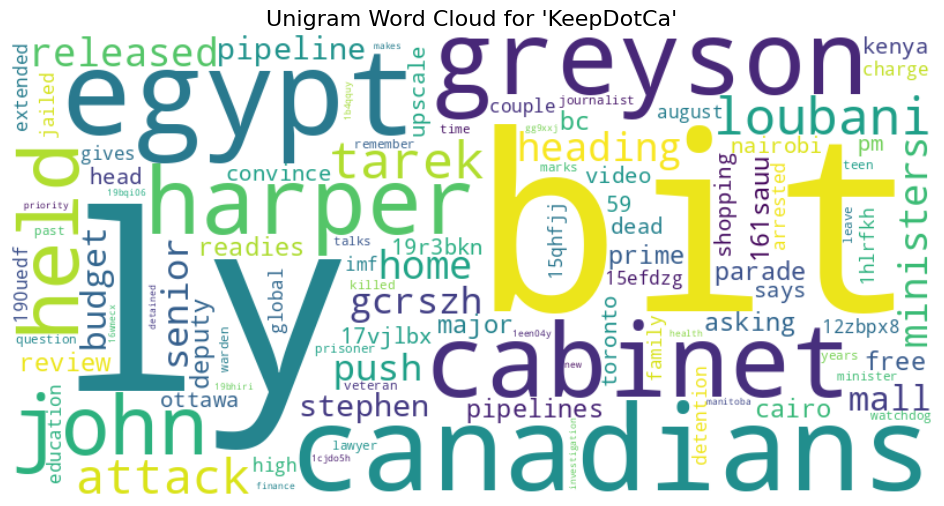

In [25]:
def print_author_wordcloud_unigram(df, username, stopwords = custom_stopwords, max_words=100):
    """
    Generate and display a unigram word cloud for a given author's posts,
    and print the word frequencies.
    Args:
        df (pd.DataFrame): DataFrame with 'author' and 'content' columns.
        username (str): Author to generate the word cloud for.
        max_words (int): Maximum number of words in the word cloud.
    """

    author_df = df[df['author'] == username]

    if author_df.empty:
        print(f"No posts found for author: {username}")
        return

    text = " ".join(author_df['content'].dropna().astype(str))

    # Vectorize the text to get unigram frequencies

    vectorizer = CountVectorizer(stop_words=custom_stopwords).fit([text])
    unigrams = vectorizer.transform([text])
    unigram_freq = dict(zip(vectorizer.get_feature_names_out(), unigrams.toarray().sum(axis=0)))

    # Print the frequencies sorted by count
    print(', '.join(f"{word}: {int(freq)}" for word, freq in sorted(unigram_freq.items(), key=lambda x: x[1], reverse=True)[:max_words]))

    # Generate word cloud using the word frequencies
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=max_words).generate_from_frequencies(unigram_freq)

    # Display
    plt.figure(figsize=(15, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Unigram Word Cloud for '{username}'", fontsize=16)
    plt.show()


print_author_wordcloud_unigram(df, "KeepDotCa")

### Bigram Wordcloud

bit ly: 34, john greyson: 11, canadians held: 9, greyson tarek: 9, held bit: 9, tarek loubani: 9, heading home: 8, cabinet ministers: 7, egypt greyson: 7, egypt heading: 7, gcrszh egypt: 7, home canadians: 7, loubani released: 7, ly gcrszh: 7, released egypt: 7, greyson john: 6, harper pipeline: 6, 161sauu bc: 4, attack canadians: 4, bc cabinet: 4, cabinet readies: 4, harper cabinet: 4, ly 161sauu: 4, major pipelines: 4, ministers senior: 4, parade cabinet: 4, pipelines push: 4, push parade: 4, readies major: 4, senior bit: 4, 17vjlbx harper: 3, 19r3bkn attack: 3, 59 dead: 3, canadians 59: 3, canadians john: 3, convince bit: 3, dead upscale: 3, head convince: 3, kenya mall: 3, ly 17vjlbx: 3, ly 19r3bkn: 3, mall attack: 3, mall bit: 3, ministers head: 3, nairobi shopping: 3, pipeline push: 3, pm harper: 3, push senior: 3, says canadians: 3, senior cabinet: 3, shopping mall: 3, toronto bit: 3, upscale nairobi: 3, video pm: 3, 12zbpx8 budget: 2, 15efdzg canadians: 2, 15qhfjj egypt: 2, 190

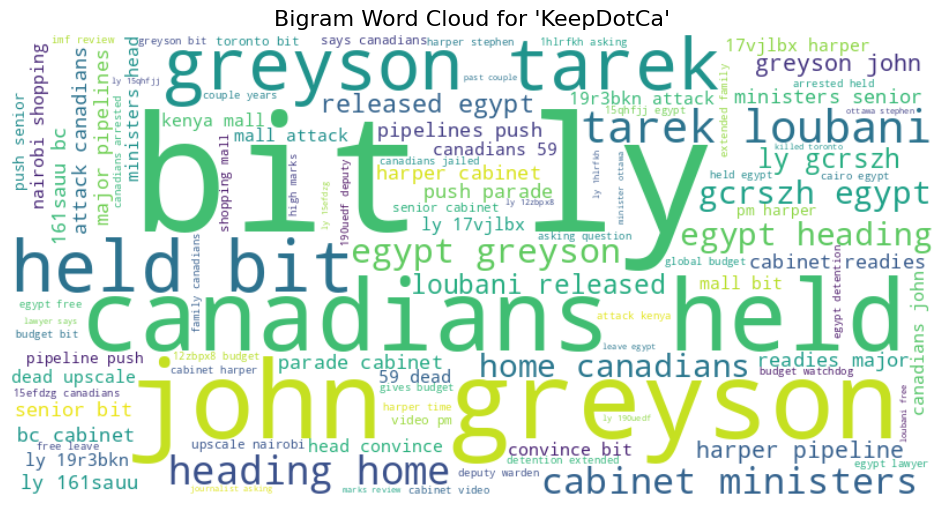

In [26]:
def print_author_wordcloud_bigram(df, username,stopwords = custom_stopwords, max_words=100):
    """
    Generate and display a bigram word cloud for a given author's posts.

    Args:
        df (pd.DataFrame): DataFrame with 'author' and 'content' columns.
        username (str): Author to generate the word cloud for.
        max_words (int): Maximum number of bigrams in the word cloud.
    """
    author_df = df[df['author'] == username]
    if author_df.empty:
        print(f"No posts found for author: {username}")
        return

    text = " ".join(author_df['content'].dropna().astype(str))

    # Initialize bigram vectorizer (2-word phrases), removing English stopwords
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words=custom_stopwords).fit([text])

    # Transform the text into a bigram frequency matrix
    bigrams = vectorizer.transform([text])

    # Create a dictionary mapping bigrams to their counts
    bigram_freq = dict(zip(vectorizer.get_feature_names_out(), bigrams.toarray().sum(axis=0)))

    # Print bigrams and their counts
    print(', '.join(f"{bigram}: {int(count)}" for bigram, count in sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)))

    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=max_words).generate_from_frequencies(bigram_freq)

    plt.figure(figsize=(15, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Bigram Word Cloud for '{username}'", fontsize=16)
    plt.show()


print_author_wordcloud_bigram(df, "KeepDotCa")


# Graphs

Imports

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D  # for edge legend entry

## Authors Hashtags Bipartite Graph
This bipartite graph visualizes the relationship between key authors and the hashtags they used within a specific topic.

In [28]:
def build_topic_author_hashtag_graph(df, authors_tfidf_dict, topic_id, top_percent=1):
    """
    Build bipartite graph where nodes are authors and hashtags and edges represent usage of hashtags by authors.
    Args:
        df (pd.DataFrame): DataFrame with columns 'author' (list), 'hashtags', 'topic'.
        authors_tfidf_dict (dict): Nested dict {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 1 for the top 1%) — only authors with the highest TF-IDF scores within this percentile are included.
    Returns:
        networkx.Graph
    """

    title = "Key Authors and Hashtags Bipartite Graph"
    explanation = f"""Topic: {topic_id}, Threshold: {top_percent}% \n
    Blue nodes represent key authors (based on TF-IDF scores), and red nodes represent hashtags.\n
    An edge connects an author to a hashtag if the author used that hashtag in the selected topic."""
    G = nx.Graph(title = title, explanation=explanation, topic="topic_id", top_percent=top_percent)

    for _, row in df.iterrows():

        author = row['author']

        # Skip rows that do not belong
        if row['topic'] != topic_id or not is_key_author(authors_tfidf_dict, topic_id, author, top_percent):
            continue

        # Add author node
        G.add_node(author, bipartite=0, type='author', color='skyblue')
        # Add hashtags' nodes and edge btween author and usded hashtag
        for hashtag in row['hashtags']:
            G.add_node(hashtag, bipartite=1, type='hashtag', color='lightcoral')
            G.add_edge(author, hashtag)

    return G

G = build_topic_author_hashtag_graph(df, authors_tfidf_dict, topic_id=2)

[find_topic_key_authors] topic: 2, Number of autores: 742, Number of key autores 7, top_percent= 1


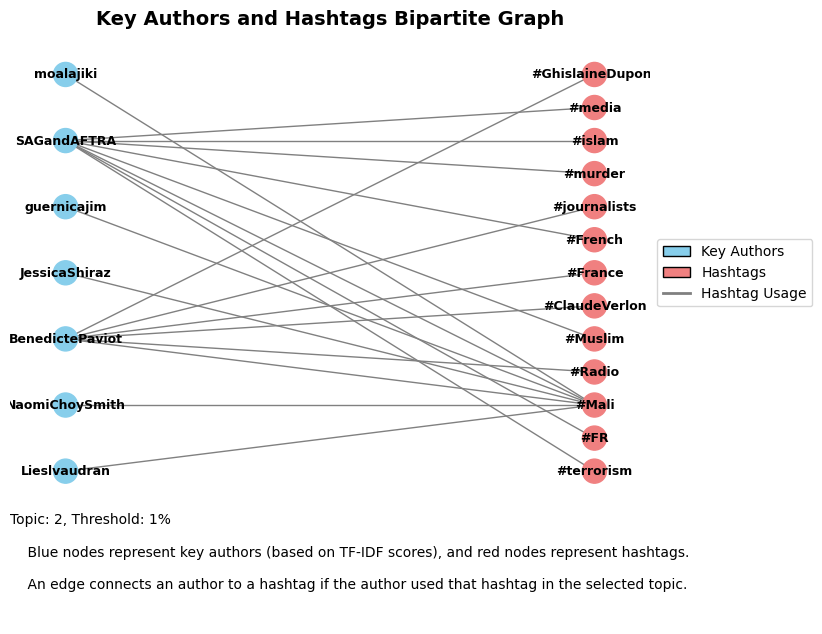

In [29]:
top_nodes = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
pos = nx.bipartite_layout(G, top_nodes)
node_colors = [G.nodes[n]['color'] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=9, font_weight='bold', edge_color='gray')

plt.title(G.graph['title'], fontsize=14, fontweight='bold')

plt.text(0.0, -0.0, G.graph['explanation'], ha='left',va='top',transform=plt.gca().transAxes, fontsize=10,wrap=True)

legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Key Authors'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Hashtags'),
    Line2D([0], [0], color='gray', lw=2, label='Hashtag Usage')
]
plt.legend( handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.5)

plt.axis('off')
plt.show()

## Behavioral Similarity Graph
This Behavioral Similarity Graph illustrates key authors and the hashtags they used within a specific topic.
Blue nodes represent authors, red nodes represent hashtags, and edges indicate usage.

In [81]:
from itertools import combinations

def build_author_similarity_graph(df, authors_tfidf_dict, topic_id, top_percent=1):
    """
    Builds a graph where nodes are key-authors and edges connect authors who used at least one common hashtag.
    Args:
        df (pd.DataFrame): DataFrame with 'author' (list), 'hashtags' (list), 'topic'.
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic to filter by.
        top_percent (float): Threshold for selecting top authors.
    Returns:
        networkx.Graph
    """

    title = "Key Author Behavioral Similarity Graph"
    topic = topic_id_to_title[topic_id]
    explanation = f"""Topic_id: {topic_id}, Topic: {topic}
                      \nKey Authors' Threshold: {top_percent}%
                      \nNode lable: author's name, tf-idf score.
                      \nEdge width represents number of shared hashtags between authors"""
    G = nx.Graph(title = title, explanation=explanation,topic_id=topic_id, topic=topic, top_percent=top_percent)

    # Build author_hashtags_dict {author: set of hashtags}
    key_author_hashtags_dict = defaultdict(set)
    for _, row in df.iterrows():

        author = row['author']

        # Filters only relevant rows.
        if row['topic'] != topic_id or not is_key_author(authors_tfidf_dict, topic_id, author, top_percent):
            continue

        key_author_hashtags_dict[author].update(row['hashtags'])

    # Add authors nodes
    for author in key_author_hashtags_dict.keys():
        G.add_node(author, score=authors_tfidf_dict[topic_id][author] ,color='skyblue')

    # Add edges between authors who share at least one hashtag
    for a1, a2 in combinations(key_author_hashtags_dict.keys(), 2):
        shared_hashtags = key_author_hashtags_dict[a1] & key_author_hashtags_dict[a2]
        if shared_hashtags:
            G.add_edge(a1, a2, weight=len(shared_hashtags))

    return G

G = build_author_similarity_graph(df, authors_tfidf_dict, topic_id=500)

[find_topic_key_authors] topic: 500, Number of autores: 1054, Number of key autores 10, top_percent= 1


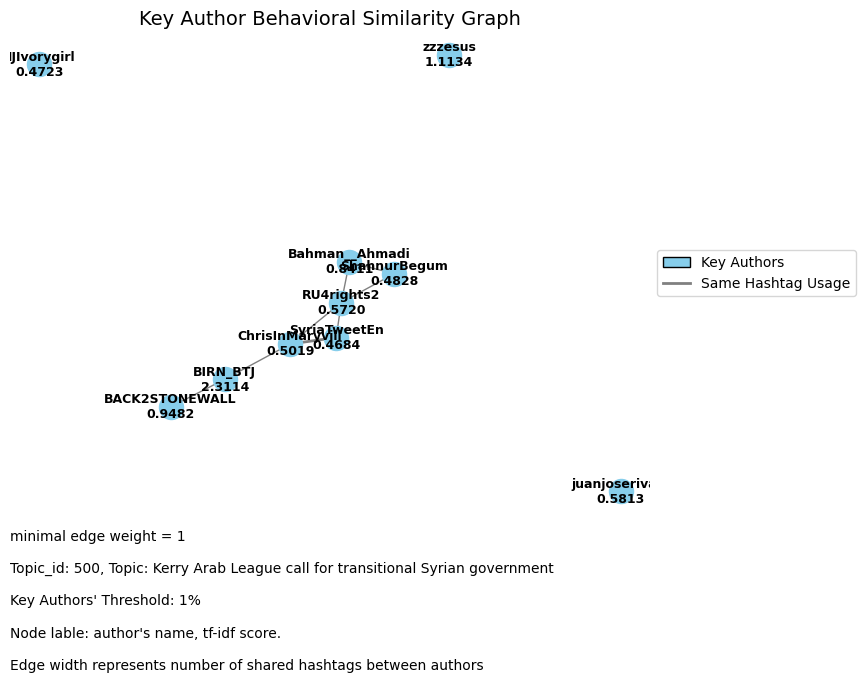

+---+-----------------+----------+-----------------------------------------------------------+-----------------+-----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------+-----------------------+
|   |     Authors     | Topic Id |                           Topic                           | Number of Posts | Average Posts' TF-IDF Score |                                                            Hashtags (Counts)                                                            |                     Topic (Frequencies)                      | Author's TF-IDF Score |
+---+-----------------+----------+-----------------------------------------------------------+-----------------+-----------------------------+--------------------------------------------------------------------------------------------------------------------------

In [85]:
minimal_edge_weight = 1 # Filter by the weight = Number of sharder hastags.


filtered_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= minimal_edge_weight]
edge_weights = [G.edges[e]['weight'] for e in filtered_edges]

labels = {node: f"{node}\n{G.nodes[node]['score']:.4f}" for node in G.nodes()}

nx.draw_spring(G, with_labels=True, labels=labels, node_color='skyblue', font_size=9, font_weight='bold', edge_color='gray',edgelist = filtered_edges, width = edge_weights)
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Key Authors'),
    Line2D([0], [0], color='gray', lw=2, label='Same Hashtag Usage')
]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.5)
plt.title(G.graph["title"], fontsize=14)
plt.text(0.0, -0.0, f"\nminimal edge weight = {minimal_edge_weight}\n\n" + G.graph["explanation"]  , ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, wrap=True)
plt.axis('off')
plt.show()

summary_df = summarize_author_activity(df, author=G.nodes, topic_id_to_title= topic_id_to_title, topic_id = G.graph['topic_id'])
print(tabulate(summary_df, headers='keys', tablefmt='pretty'))

In [87]:
author_posts(df, "ChrisInMaryvill", 500).head(20)

,topic,title,date,content
7231,500,Kerry Arab League call for transitional Syrian...,2012-07-02 00:07:38,UN envoy calls for transitional government in ...
7232,500,Kerry Arab League call for transitional Syrian...,2012-07-02 00:07:38,UN envoy calls for transitional government in ...


# Statistics

## List of Extracted Topics

In [65]:
topic_counts_df = df['topic'].value_counts().reset_index()
topic_counts_df.columns = ['topic', 'post count']  # rename for clarity
topic_counts_df['title'] = topic_counts_df['topic'].apply(lambda x: topic_id_to_title[x])

print("Head of topic_counts_df:")
topic_counts_df.head(10)
# print(tabulate(topic_counts_df.head(), headers='keys', tablefmt='pretty'))

Head of topic_counts_df:


,topic,post count,title
0,123,2640,Canadians held without charge in Egypt headed ...
1,924,2522,US ambassador denounces Gaza terrorist tunnels
2,142,2514,Congress lumbers while threatened default looms
3,297,2504,Hawkish MKs call to rethink peace talks after ...
4,107,2498,Betrayals banks and Bibi
5,153,2495,Dayan pushed PM Meir to consider using nuclear...
6,602,2494,Netanyahu vows No nukes for Irans dark regime
7,865,2490,Trouble in Tunisia
8,759,2418,Several Americans among Kenya attackers says o...
9,58,2407,American UN ambassador We wont cut bad deal wi...


## Topic's Top Entitie and Authors

In [33]:
def print_entity_score_stats(dict_item_score, topic_id, entity_type, remove_zeroes = True, top_n = 10):
    """
    Prints statistics for a specific entity type in a given topic.
    Args:
        dict_item_score (dict) {topic: {entity: score}}
        topic_id (int): Topic identifier.
        entity_type (str): Entity type (e.g., 'hashtags', 'mentions').
        top_n (int): The number of top items to present.
        remove_zeroes (bool): If true, removes items with a score of 0.
    """
    scores = list(dict_item_score[topic_id].values())
    if not scores:
        print(f"No scores found for {entity_type}")
        return
    print(f"--- Stats for Topic Id: {topic_id}, Entity Type: {entity_type} ---")
    print(f"Topic: {topic_id_to_title[topic_id]}")
    print(f"Min: {np.min(scores):.4f}")
    print(f"Max: {np.max(scores):.4f}")
    print(f"Mean: {np.mean(scores):.4f}")
    print(f"Std: {np.std(scores):.4f}")
    print(f"Median: {np.median(scores):.4f}")

    sorted_entities_by_scores = (sorted(dict_item_score[topic_id].items(), key=lambda x: x[1], reverse=True))[:top_n]
    if remove_zeroes:
        sorted_entities_by_scores = [(entity, score) for entity, score in sorted_entities_by_scores if score > 0]

    print(f"Top {top_n} {entity_type}:")
    for entity, score in sorted_entities_by_scores:
        print(f"\t \t {entity:<15} Score: {score:.4f}")
    print()


print_entity_score_stats(hashtags_tfidf_dict, topic_id=123, entity_type="Hashtags")
print_entity_score_stats(mention_tfidf_dict, topic_id=123, entity_type="Mentions")
print_entity_score_stats(authors_tfidf_dict, topic_id=123, entity_type="Authors")
# new entity dict's structure: {topic: {entity: tfidf_score}}
# old entity dict's structure: {(topic, entity): tfidf_score}

--- Stats for Topic Id: 123, Entity Type: Hashtags ---
Topic: Canadians held without charge in Egypt headed home
Min: 0.0003
Max: 0.2411
Mean: 0.0093
Std: 0.0187
Median: 0.0053
Top 10 Hashtags:
	 	 #Canadians      Score: 0.2411
	 	 #Greyson        Score: 0.1118
	 	 #Egypt          Score: 0.1048
	 	 #Toronto        Score: 0.0692
	 	 #Loubani        Score: 0.0692
	 	 #freetarekandjohn Score: 0.0671
	 	 #FreeTarekandJohn Score: 0.0465
	 	 #cdnpoli        Score: 0.0385
	 	 #Canada         Score: 0.0373
	 	 #CDNpoli        Score: 0.0371

--- Stats for Topic Id: 123, Entity Type: Mentions ---
Topic: Canadians held without charge in Egypt headed home
Min: 0.2321
Max: 0.8387
Mean: 0.3955
Std: 0.1645
Median: 0.4134
Top 10 Mentions:
	 	 @pmharper       Score: 0.8387
	 	 @EtCRbA         Score: 0.4424
	 	 @brandon_dnl    Score: 0.4424
	 	 @peterkimglobal Score: 0.4424
	 	 @Intentdotcom   Score: 0.4424
	 	 @huffpostca     Score: 0.4134
	 	 @DFATDCanada    Score: 0.3434
	 	 @joseluisrubio  Score: 0.

## Topic's Top Posts

In [34]:
def find_topic_top_posts(df, topic_id, score_col_name="post_topic_tfidf", top_n=5):
    """
    Prints the top N posts for a given topic ID.
    Args:
        df (pd.DataFrame): DataFrame with at least 'topic_id' and 'title' columns.
        topic_id (int or str): The topic ID to filter by.
        top_n (int): Number of top posts to display.
        score_col_name (str or None): Column name of posts' scores.
    """
    topic_df = df[df['topic'] == topic_id]
    topic_df = topic_df[['topic', 'title', 'author', 'content', 'post_topic_tfidf', 'date', 'author_score', 'c_post_id']]
    if topic_df.empty:
        print(f"No posts found for topic {topic_id}")
        return


    top_posts = topic_df.sort_values(by=score_col_name, ascending=False).head(top_n)
    return top_posts


topic_top_post_df = find_topic_top_posts(df, topic_id=123)
topic_top_post_df
# print(tabulate(topic_top_post_df, headers='keys', tablefmt='grid', stralign='left'))

,topic,title,author,content,post_topic_tfidf,date,author_score,c_post_id
487546,123,Canadians held without charge in Egypt headed ...,MichaelSerapio,# Canadians John # Greyson and Dr Tarek # Loub...,0.550368,2013-10-07 15:52:52,7.60252,d27e4c19-c3dd-3fac-be51-e2b638baff9a
351398,123,Canadians held without charge in Egypt headed ...,MichaelSerapio,# Canadians John # Greyson and Dr Tarek # Loub...,0.550368,2013-10-07 15:52:52,7.60252,d27e4c19-c3dd-3fac-be51-e2b638baff9a
349878,123,Canadians held without charge in Egypt headed ...,ayateldewary,Two # Canadians released from prison in # Egyp...,0.430839,2013-10-06 07:48:21,1.81496,04395742-f714-36f7-97b9-5666b8dbcb71
349931,123,Canadians held without charge in Egypt headed ...,SarahVirro,Greyson and Loubani have finally arrived home!...,0.428023,2013-10-12 02:24:56,2.95625,0beb77ea-607f-36b4-9318-5f5ce78e8fd1
487344,123,Canadians held without charge in Egypt headed ...,Leftpalm,# Canadians John Greyson & Tarek Loubani held ...,0.415093,2013-10-06 20:29:38,4.03705,9212f745-f51b-3479-a5c9-2e6649186229


## TF-IDF Scores Histogram

In [35]:
def get_all_tfidf_scores(entity_tfidf_dict):
    """
    Collects all TF-IDF scores from a nested dict.
    Args:
        entity_tfidf_dict (dict): Nested dict of entity TF-IDF scores {topic: {entity: score}}.
    Returns:
        list: All TF-IDF scores from all entities in all topics.
    """
    all_tfidf_scores = []
    for entity_scores in entity_tfidf_dict.values():
        all_tfidf_scores.extend(entity_scores.values())
    return all_tfidf_scores

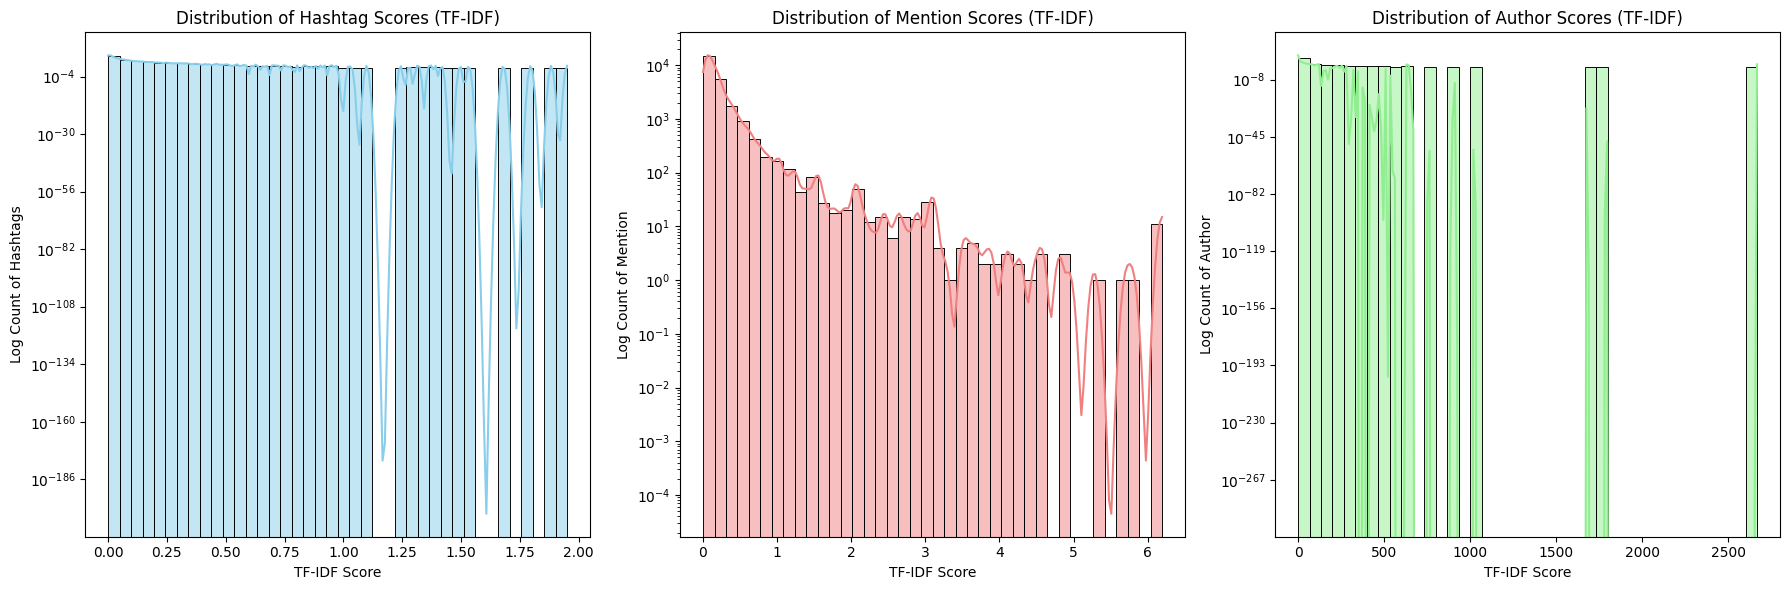

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Collecting Scores ---

all_hashtag_scores = get_all_tfidf_scores(hashtags_tfidf_dict)
all_mention_scores = get_all_tfidf_scores(mention_tfidf_dict)
all_author_scores = get_all_tfidf_scores(authors_tfidf_dict)

# --- Plotting the Histograms ---

plt.figure(figsize=(18, 6)) # Set the overall figure size

# Histogram for Hashtag Scores
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
if all_hashtag_scores:
    sns.histplot(all_hashtag_scores, kde=True, bins=40, color='skyblue')
    plt.title('Distribution of Hashtag Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Log Count of Hashtags') # Y-axis label changed to English
    plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Hashtag Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

# Histogram for Mention Scores
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
if all_mention_scores:
    sns.histplot(all_mention_scores, kde=True, bins=40, color='lightcoral')
    plt.title('Distribution of Mention Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Log Count of Mention') # Y-axis label changed to English
    plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Mention Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

# Histogram for Author Scores
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
if all_author_scores:
    sns.histplot(all_author_scores, kde=True, bins=40, color='lightgreen')
    plt.title('Distribution of Author Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Log Count of Author') # Y-axis label changed to English
    plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Author Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

plt.tight_layout()
plt.show()

# Min Max Scale

In [37]:
from collections import defaultdict

def min_max_normalize_by_topic(entity_tfidf_dict):
    """
    Normalize TF-IDF scores per topic using Min-Max normalization.
    Args:
        entity_tfidf_dict (dict): Nested dict {topic: {entity: score}}.
    Returns:
        dict: Nested dict {topic: {entity: normalized_score}}.
    """
    topic_to_stats = {}
    for topic, entity_scores in entity_tfidf_dict.items():
        scores = entity_scores.values()
        min_val = min(scores)
        max_val = max(scores)
        topic_to_stats[topic] = (min_val, max_val)

    norm_dict = defaultdict(lambda: defaultdict(float))
    for topic, entity_scores in entity_tfidf_dict.items():
        min_val, max_val = topic_to_stats[topic]
        for entity, score in entity_scores.items():
            if max_val - min_val == 0:
                norm_score = 0
            else:
                norm_score = (score - min_val) / (max_val - min_val)
            norm_dict[topic][entity] = norm_score

    return dict(norm_dict)

In [38]:
from itertools import islice

def print_nested_dict_preview(nested_dict, num_topics=2, num_entities=2):
    """
    Print a preview of a nested .
    Args:
        nested_dict (dict): The nested dictionary to print, dict: {topic: {entity: score}}.
        num_topics (int): number of topics to show.
        num_entities (int or None): Max number of entities per topic to show (None = show all).
    """
    for topic, entity_scores in islice(nested_dict.items(), num_topics):
        print(f"Topic: {topic}")
        for entity, score in islice(entity_scores.items(), num_entities):
            print(f"  {entity}: {score}")
        print()  # Blank line between topics
    print("--- End ---")
    print()

In [39]:
# Apply normalization to each entity type
norm_hashtag_scores = min_max_normalize_by_topic(hashtags_tfidf_dict)
norm_mention_scores = min_max_normalize_by_topic(mention_tfidf_dict)
norm_author_scores = min_max_normalize_by_topic(authors_tfidf_dict)


print("--- raw_hashtag_scores ---\n")
print_nested_dict_preview(hashtags_tfidf_dict)
print("--- norm_hashtag_scores ---\n")
print_nested_dict_preview(norm_hashtag_scores)

--- raw_hashtag_scores ---

Topic: 2
  #Uganda: 0.07282823658128308
  #News19: 0.013815719017426604

Topic: 770
  #Democratics: 0.008016265930001959
  #gop: 0.0019164106800505524

--- End ---

--- norm_hashtag_scores ---

Topic: 2
  #Uganda: 0.34860694173768036
  #News19: 0.06280166448947086

Topic: 770
  #Democratics: 0.0540495487123251
  #gop: 0.011707986187959579

--- End ---



In [40]:
import pandas as pd

def show_top_entities_before_after_normalization(original_dict, normalized_dict, topic_id, top_n=10):
    """
    Print top-N entities for a specific topic before and after normalization.

    Args:
        nested_dict (dict): {topic: {entity: score}}.
        original_dict (dict): {topic: {entity: raw_tfidf_score}}
        normalized_dict (dict): {topic: {entity: normalized_tfidf_score}}
        topic_id (int or str): the topic to filter by
        top_n (int): number of top entities to display
    """
    # Filter entries for the given topic
    data = []
    for entity in original_dict[topic_id].keys():
            data.append({
                'Entity': entity,
                'Raw TF-IDF': original_dict[topic_id][entity],
                'Normalized TF-IDF': normalized_dict[topic_id][entity]
            })

    df = pd.DataFrame(data)

    # Sort and select top N by raw TF-IDF
    top_raw = df.sort_values(by='Raw TF-IDF', ascending=False).head(top_n)
    print(f"\nTop {top_n} entities for topic {topic_id} — by **Raw TF-IDF**:\n")
    print(top_raw.to_string(index=False))

    # Sort and select top N by normalized TF-IDF
    top_norm = df.sort_values(by='Normalized TF-IDF', ascending=False).head(top_n)
    print(f"\nTop {top_n} entities for topic {topic_id} — by **Normalized TF-IDF**:\n")
    print(top_norm.to_string(index=False))


show_top_entities_before_after_normalization(
    hashtags_tfidf_dict,
    norm_hashtag_scores,
    topic_id=2,
    top_n=10
)


Top 10 entities for topic 2 — by **Raw TF-IDF**:

      Entity  Raw TF-IDF  Normalized TF-IDF
       #Mali    0.207327           1.000000
     #Uganda    0.072828           0.348607
        #RFI    0.061498           0.293734
     #French    0.050392           0.239948
#journalists    0.048810           0.232283
       #COYI    0.044259           0.210242
        #BPL    0.044259           0.210242
 #journalist    0.044137           0.209653
          #2    0.037010           0.175132
      #Marea    0.034611           0.163514

Top 10 entities for topic 2 — by **Normalized TF-IDF**:

      Entity  Raw TF-IDF  Normalized TF-IDF
       #Mali    0.207327           1.000000
     #Uganda    0.072828           0.348607
        #RFI    0.061498           0.293734
     #French    0.050392           0.239948
#journalists    0.048810           0.232283
       #COYI    0.044259           0.210242
        #BPL    0.044259           0.210242
 #journalist    0.044137           0.209653
          #

Normalize the scores to ensure fair comparison across different entity types.

In [41]:
def compute_mean_score(scores):
    return np.mean(scores) if scores else 0

df['mean_hashtag_score'] = df['hashtag_scores'].apply(compute_mean_score)
# df['mean_url_score'] = df['url_scores'].apply(compute_mean_score)
df['mean_mention_score'] = df['mention_scores'].apply(compute_mean_score)
df['mean_author_score'] = df['author_score'].apply(compute_mean_score)

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score,mean_hashtag_score,mean_mention_score,mean_author_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828,0.35207,0.072828,0,0.35207
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000,0.00000,0.000000,0,0.00000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000,0.00000,0.000000,0,0.00000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000,0.25138,0.000000,0,0.25138
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000,0.00000,0.000000,0,0.00000


In [42]:
df['min_max_post_score'] = (
    df['mean_hashtag_score'] +
    # df['mean_url_score'] +
    df['mean_mention_score'] +
    df['mean_author_score']
)

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score,mean_hashtag_score,mean_mention_score,mean_author_score,min_max_post_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828,0.35207,0.072828,0,0.35207,0.424898
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000,0.00000,0.000000,0,0.00000,0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000,0.00000,0.000000,0,0.00000,0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000,0.25138,0.000000,0,0.25138,0.251380
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000,0.00000,0.000000,0,0.00000,0.000000


In [43]:
sorted_posts = df.sort_values(by=['topic', 'min_max_post_score'], ascending=[True, False])

In [44]:
num_topics = sorted_posts['topic'].unique()[:2] # Take only the first 2 unique topics

for topic in num_topics:
    print(f"\nTop 5 Posts for Topic {topic}:")
    top_posts = sorted_posts[sorted_posts['topic'] == topic].head(5)
    for idx, row in top_posts.iterrows():
        print(f"Post ID: {row['c_post_id']}, Key Post Score: {row['min_max_post_score']:.4f}")
        print(f"Content: {row['content']}")
        print(f"Hashtags: {row['hashtags']}")
        # print(f"URL Scores: {row['url_scores']}")
        print(f"Mention Scores: {row['mention_scores']}")
        print(f"Author Score: {row['author_score']}")
        print()



Top 5 Posts for Topic 0:
Post ID: 164cf6b4-a379-3fc7-80da-111ed6642364, Key Post Score: 6.6341
Content: Olive tree outside Jerusalem Old City walls...
http://dld.bz/b5HXU # photo # Jerusalem # tree
Hashtags: ['#photo', '#Jerusalem', '#tree']
Mention Scores: []
Author Score: 6.59209

Post ID: 3fab6d47-8661-39a7-8338-eda662a55ff6, Key Post Score: 6.6341
Content: Olive tree outside Jerusalem Old City walls...
http://dld.bz/b5HXU # photo # Jerusalem # tree
Hashtags: ['#photo', '#Jerusalem', '#tree']
Mention Scores: []
Author Score: 6.59209

Post ID: a103cb37-a7df-3922-b093-095447ac8397, Key Post Score: 6.6341
Content: Olive tree outside Jerusalem Old City walls...
http://dld.bz/b5HXU # photo # Jerusalem # tree
Hashtags: ['#photo', '#Jerusalem', '#tree']
Mention Scores: []
Author Score: 6.59209

Post ID: d6d64208-d578-3dbd-b458-951c1e8c1439, Key Post Score: 6.6341
Content: Olive tree outside Jerusalem Old City walls...
http://dld.bz/b5HXU # photo # Jerusalem # tree
Hashtags: ['#photo', '#J